## Predictive Maintenance for CNC Machines

**Dataset**: NASA CMAPSS Turbofan Engine Degradation (FD001)  
**Target**: Classify engine health — Normal / Warning / Critical  
**Models**: Decision Tree, Random Forest, Gradient Boosting, XGBoost, SVM, KNN  
**Metrics**: Accuracy, Precision, Recall, F1, Confusion Matrix

### Table of Contents

1. Imports  
2. Data Loading  
3. Exploratory Data Analysis  
4. Feature Engineering  
5. Preprocessing and Class Balancing  
6. Model Training with Cross-Validation  
7. Performance Comparison  
8. Confusion Matrices  
9. Learning Curves    
10. Final Summary

#### 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

#### 2. Data Loading

In [2]:
columns = (
    ["unit", "cycle"] +
    ["op_1", "op_2", "op_3"] +
    [f"sensor_{i}" for i in range(1, 22)]
)

df = pd.read_csv("../data/train_FD001.txt", sep=r"\s+", header=None)
df.columns = columns

print("shape:", df.shape)
df.head()

shape: (20631, 26)


,unit,cycle,op_1,op_2,op_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit       20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   op_1       20631 non-null  float64
 3   op_2       20631 non-null  float64
 4   op_3       20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor_16  20631 

In [4]:
df.isnull().sum().sum()

np.int64(0)

#### 3. Exploratory Data Analysis

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [6]:
# Class Distribution (after labeling)

# We will compute RUL first, then label each row as Normal, Warning or Critical.
# - Normal   : RUL > 50  
# - Warning  : 20 < RUL <= 50  
# - Critical : RUL <= 20

max_cycles = df.groupby("unit")["cycle"].max()
df["rul"] = df.apply(lambda row: max_cycles[row["unit"]] - row["cycle"], axis=1)

def label_health(rul):
    if rul > 50:
        return 0   # Normal
    elif rul > 20:
        return 1   # Warning
    else:
        return 2   # Critical

df["health_state"] = df["rul"].apply(label_health)

labels = {0: "Normal", 1: "Warning", 2: "Critical"}
print(df["health_state"].value_counts().rename(labels))

health_state
Normal      15531
Warning      3000
Critical     2100
Name: count, dtype: int64


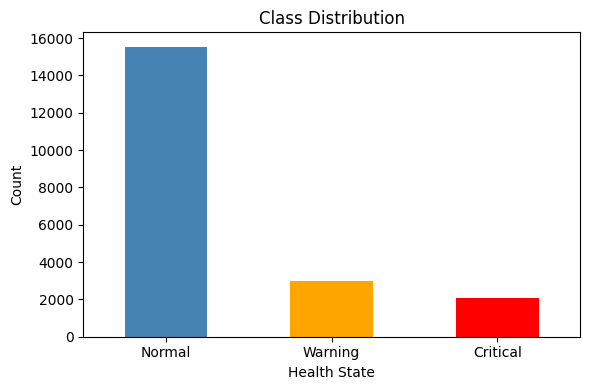

In [7]:
plt.figure(figsize=(6, 4))
df["health_state"].value_counts().rename(labels).plot(kind="bar", color=["steelblue", "orange", "red"])
plt.title("Class Distribution")
plt.xlabel("Health State")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

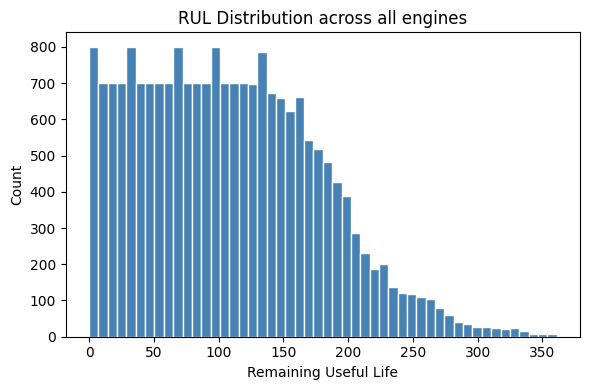

In [8]:
# RUL Distribution

plt.figure(figsize=(6, 4))
plt.hist(df["rul"], bins=50, color="steelblue", edgecolor="white")
plt.title("RUL Distribution across all engines")
plt.xlabel("Remaining Useful Life")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The distribution is right-skewed. Most observations are concentrated at lower RUL values
since every engine accumulates cycles as it degrades toward failure. This confirms that
the Critical class (RUL <= 20) will be the minority class, which we will handle using SMOTE.

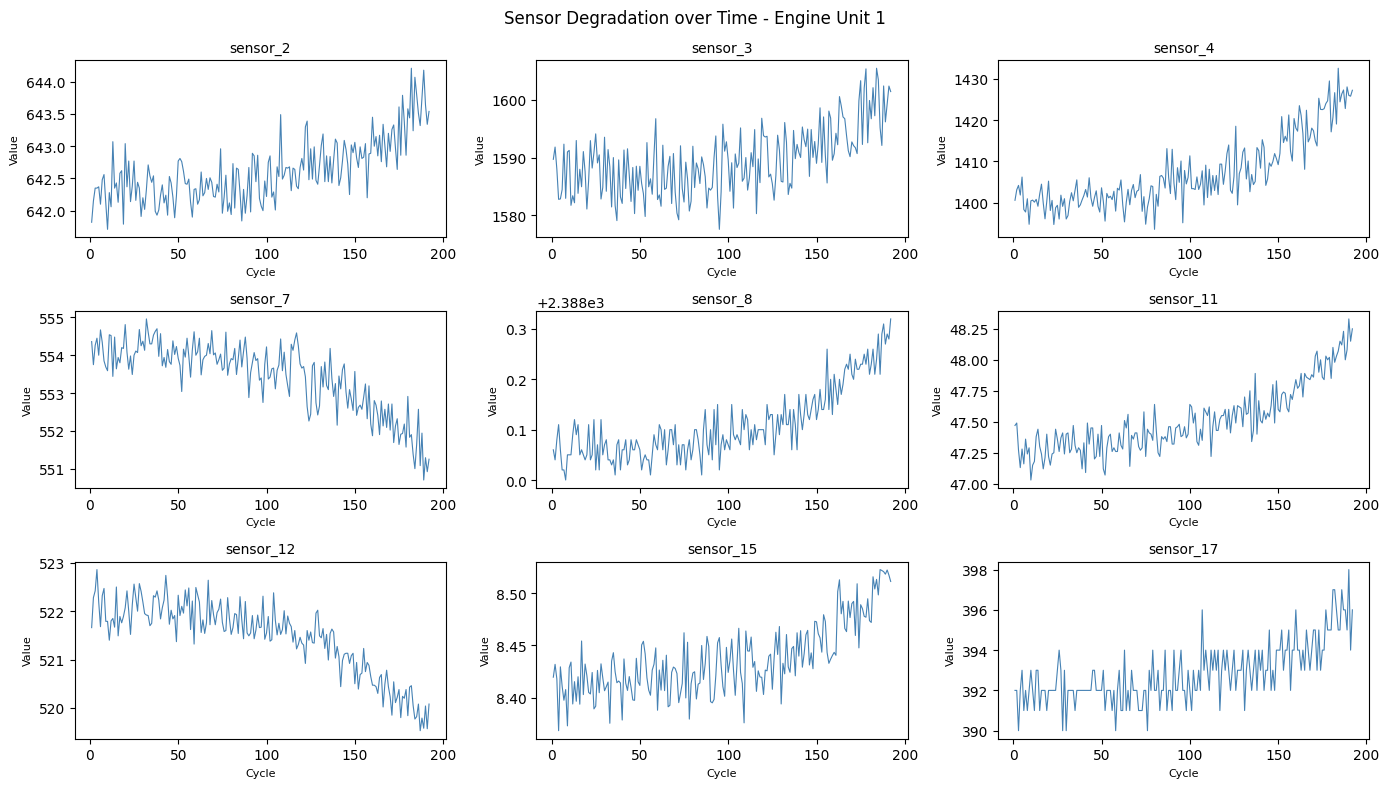

In [9]:
# Sensor Readings over Time 

sample_unit = df[df["unit"] == 1]

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
signal_sensors = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_8", "sensor_11", "sensor_12", "sensor_15", "sensor_17"]

for ax, sensor in zip(axes.flat, signal_sensors):
    ax.plot(sample_unit["cycle"], sample_unit[sensor], linewidth=0.8, color="steelblue")
    ax.set_title(sensor, fontsize=10)
    ax.set_xlabel("Cycle", fontsize=8)
    ax.set_ylabel("Value", fontsize=8)

plt.suptitle("Sensor Degradation over Time - Engine Unit 1", fontsize=12)
plt.tight_layout()
plt.show()

#### 4. Feature Engineering

In [10]:
# Drop Low-Variance Sensors
# Some sensors in FD001 are nearly constant across all cycles and carry no useful signal. We drop them to reduce noise.

df = df.sort_values(["unit", "cycle"])

all_sensors = [col for col in df.columns if col.startswith("sensor_")]
low_var = [col for col in all_sensors if df[col].std() < 0.1]
df.drop(columns=low_var, inplace=True)

signal_sensors = [col for col in df.columns if col.startswith("sensor_")]
print("dropped:", low_var)
print("signal sensors kept:", signal_sensors)

dropped: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19']
signal sensors kept: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']


In [11]:
for col in signal_sensors:
    df[f"{col}_rmean"] = df.groupby("unit")[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).mean()
    )
    df[f"{col}_rstd"] = df.groupby("unit")[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).std().fillna(0)
    )

print("rolling features added:", [c for c in df.columns if "rmean" in c or "rstd" in c])

rolling features added: ['sensor_2_rmean', 'sensor_2_rstd', 'sensor_3_rmean', 'sensor_3_rstd', 'sensor_4_rmean', 'sensor_4_rstd', 'sensor_7_rmean', 'sensor_7_rstd', 'sensor_9_rmean', 'sensor_9_rstd', 'sensor_11_rmean', 'sensor_11_rstd', 'sensor_12_rmean', 'sensor_12_rstd', 'sensor_14_rmean', 'sensor_14_rstd', 'sensor_17_rmean', 'sensor_17_rstd', 'sensor_20_rmean', 'sensor_20_rstd', 'sensor_21_rmean', 'sensor_21_rstd']


In [12]:
df.columns

Index(['unit', 'cycle', 'op_1', 'op_2', 'op_3', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12',
       'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21', 'rul',
       'health_state', 'sensor_2_rmean', 'sensor_2_rstd', 'sensor_3_rmean',
       'sensor_3_rstd', 'sensor_4_rmean', 'sensor_4_rstd', 'sensor_7_rmean',
       'sensor_7_rstd', 'sensor_9_rmean', 'sensor_9_rstd', 'sensor_11_rmean',
       'sensor_11_rstd', 'sensor_12_rmean', 'sensor_12_rstd',
       'sensor_14_rmean', 'sensor_14_rstd', 'sensor_17_rmean',
       'sensor_17_rstd', 'sensor_20_rmean', 'sensor_20_rstd',
       'sensor_21_rmean', 'sensor_21_rstd'],
      dtype='str')

In [13]:
drop_cols = ["unit", "cycle", "rul", "health_state"]
X = df.drop(columns=drop_cols)
y = df["health_state"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts().rename({0:"Normal", 1:"Warning", 2:"Critical"}))

X shape: (20631, 36)
y distribution:
 health_state
Normal      15531
Warning      3000
Critical     2100
Name: count, dtype: int64


#### 5. Preprocessing and Class Balancing

In [14]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=22)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\ntrain class distribution:\n", y_train.value_counts().rename({0:"Normal", 1:"Warning", 2:"Critical"}))
print("\ntest class distribution:\n",  y_test.value_counts().rename({0:"Normal", 1:"Warning", 2:"Critical"}))

X_train: (16504, 36)
X_test : (4127, 36)

train class distribution:
 health_state
Normal      12424
Warning      2400
Critical     1680
Name: count, dtype: int64

test class distribution:
 health_state
Normal      3107
Warning      600
Critical     420
Name: count, dtype: int64


#### 6. Model Training with Cross-Validation

In [16]:
models = {
    "SVM": SVC(kernel="rbf", C=10, class_weight="balanced", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=11, weights="distance", n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, eval_metric="mlogloss", random_state=42, n_jobs=-1),
}

print("models defined:", list(models.keys()))

models defined: ['SVM', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    fold_acc, fold_pre, fold_rec, fold_f1 = [], [], [], []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Handling Class Imbalance with SMOTE
        sm = SMOTE(random_state=22)
        X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        fold_acc.append(accuracy_score(y_val, y_pred))
        fold_pre.append(precision_score(y_val, y_pred, average="macro", zero_division=0))
        fold_rec.append(recall_score(y_val, y_pred, average="macro", zero_division=0))
        fold_f1.append(f1_score(y_val, y_pred, average="macro", zero_division=0))

    results[name] = {
        "Accuracy": round(np.mean(fold_acc), 4),
        "Precision": round(np.mean(fold_pre), 4),
        "Recall": round(np.mean(fold_rec), 4),
        "F1 Score": round(np.mean(fold_f1), 4),
    }

    print(f"{name:<20} Acc={results[name]['Accuracy']}  F1={results[name]['F1 Score']}")

SVM                  Acc=0.8968  F1=0.8314
KNN                  Acc=0.819  F1=0.7799
Decision Tree        Acc=0.8628  F1=0.7972
Random Forest        Acc=0.9167  F1=0.863
Gradient Boosting    Acc=0.9135  F1=0.854
XGBoost              Acc=0.9117  F1=0.8531


#### 7. Performance Comparison

In [18]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
results_df = results_df.sort_values("F1 Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9167,0.8566,0.8706,0.8630
1,Gradient Boosting,0.9135,0.8526,0.8555,0.8540
2,XGBoost,0.9117,0.8471,0.8599,0.8531
3,SVM,0.8968,0.8256,0.8387,0.8314
4,Decision Tree,0.8628,0.7821,0.8262,0.7972
5,KNN,0.8190,0.7595,0.8499,0.7799


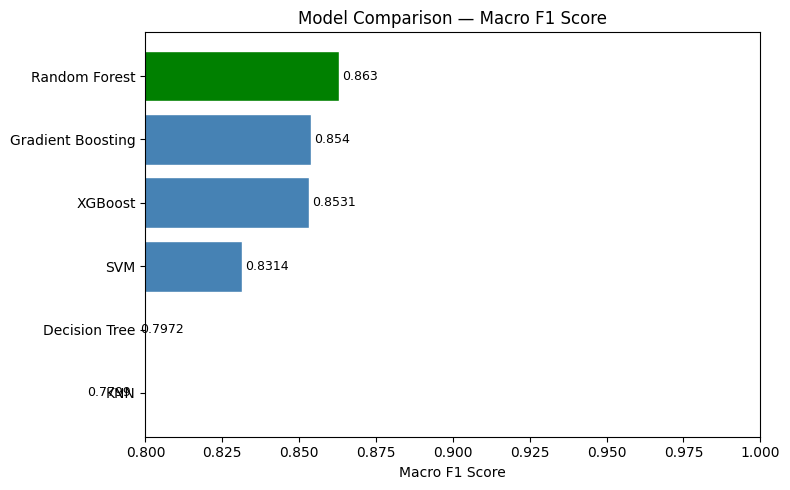

In [19]:
# F1 Score Comparison
plt.figure(figsize=(8, 5))
colors = ["green" if i == 0 else "steelblue" for i in range(len(results_df))]
plt.barh(results_df["Model"], results_df["F1 Score"], color=colors, edgecolor="white")
plt.xlabel("Macro F1 Score")
plt.title("Model Comparison — Macro F1 Score")
plt.xlim(0.8, 1.0)
plt.gca().invert_yaxis()
for i, val in enumerate(results_df["F1 Score"]):
    plt.text(val + 0.001, i, str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/f1_comparison.png", dpi=150)
plt.show()

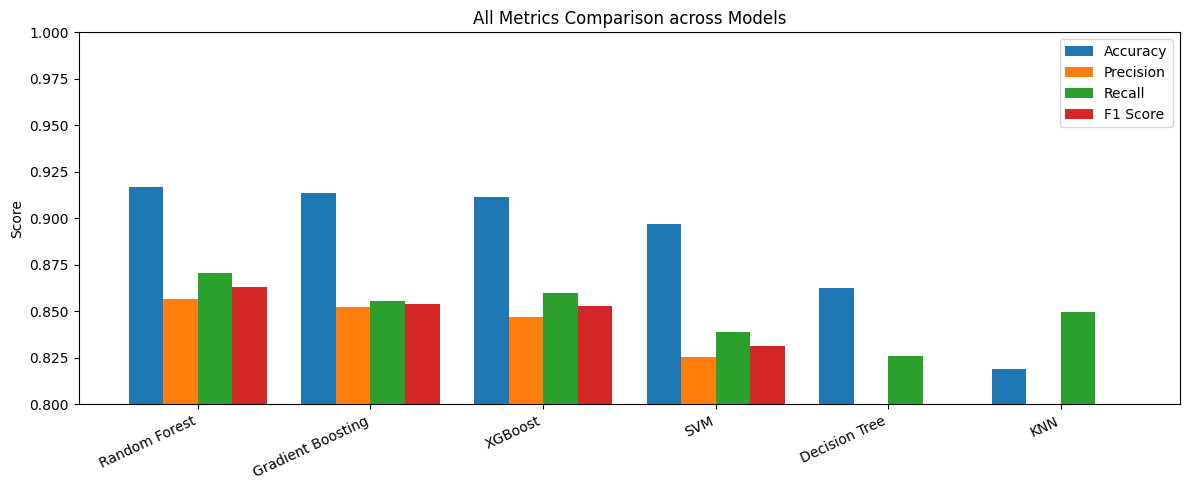

In [20]:
# All Metrics Comparison
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"], rotation=25, ha="right")
ax.set_ylim(0.8, 1.0)
ax.set_ylabel("Score")
ax.set_title("All Metrics Comparison across Models")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/all_metrics_comparison.png", dpi=150)
plt.show()

#### 8. Confusion Matrices

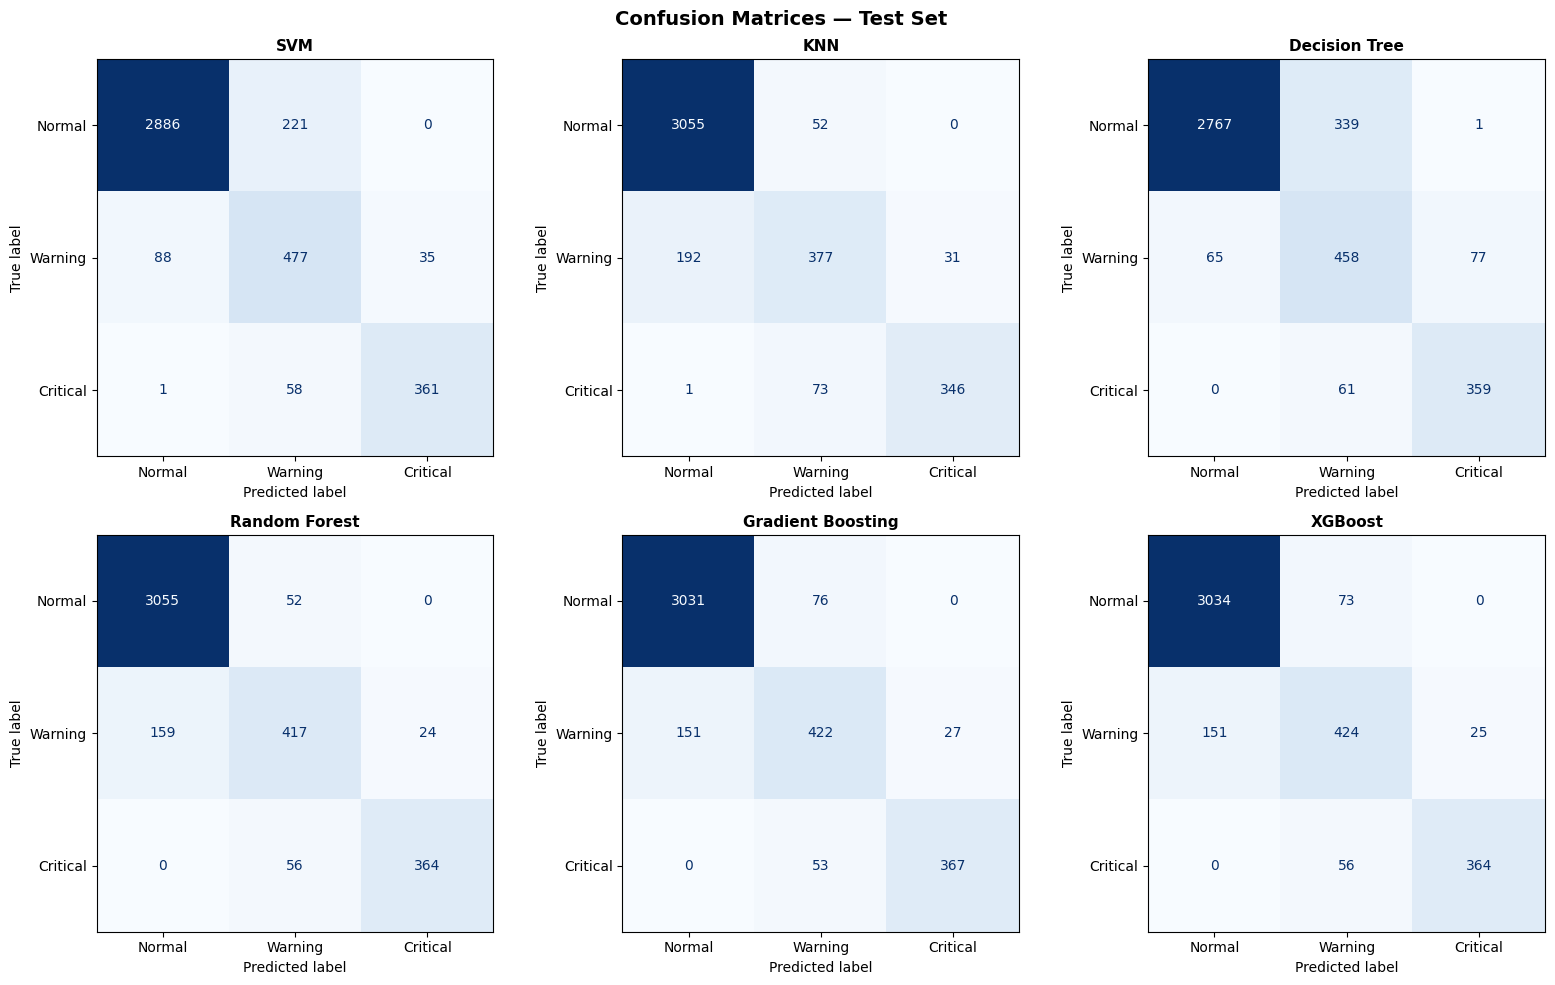

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes.flat, models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Warning", "Critical"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/confusion_matrices.png", dpi=150)
plt.show()

#### 9. Learning Curves

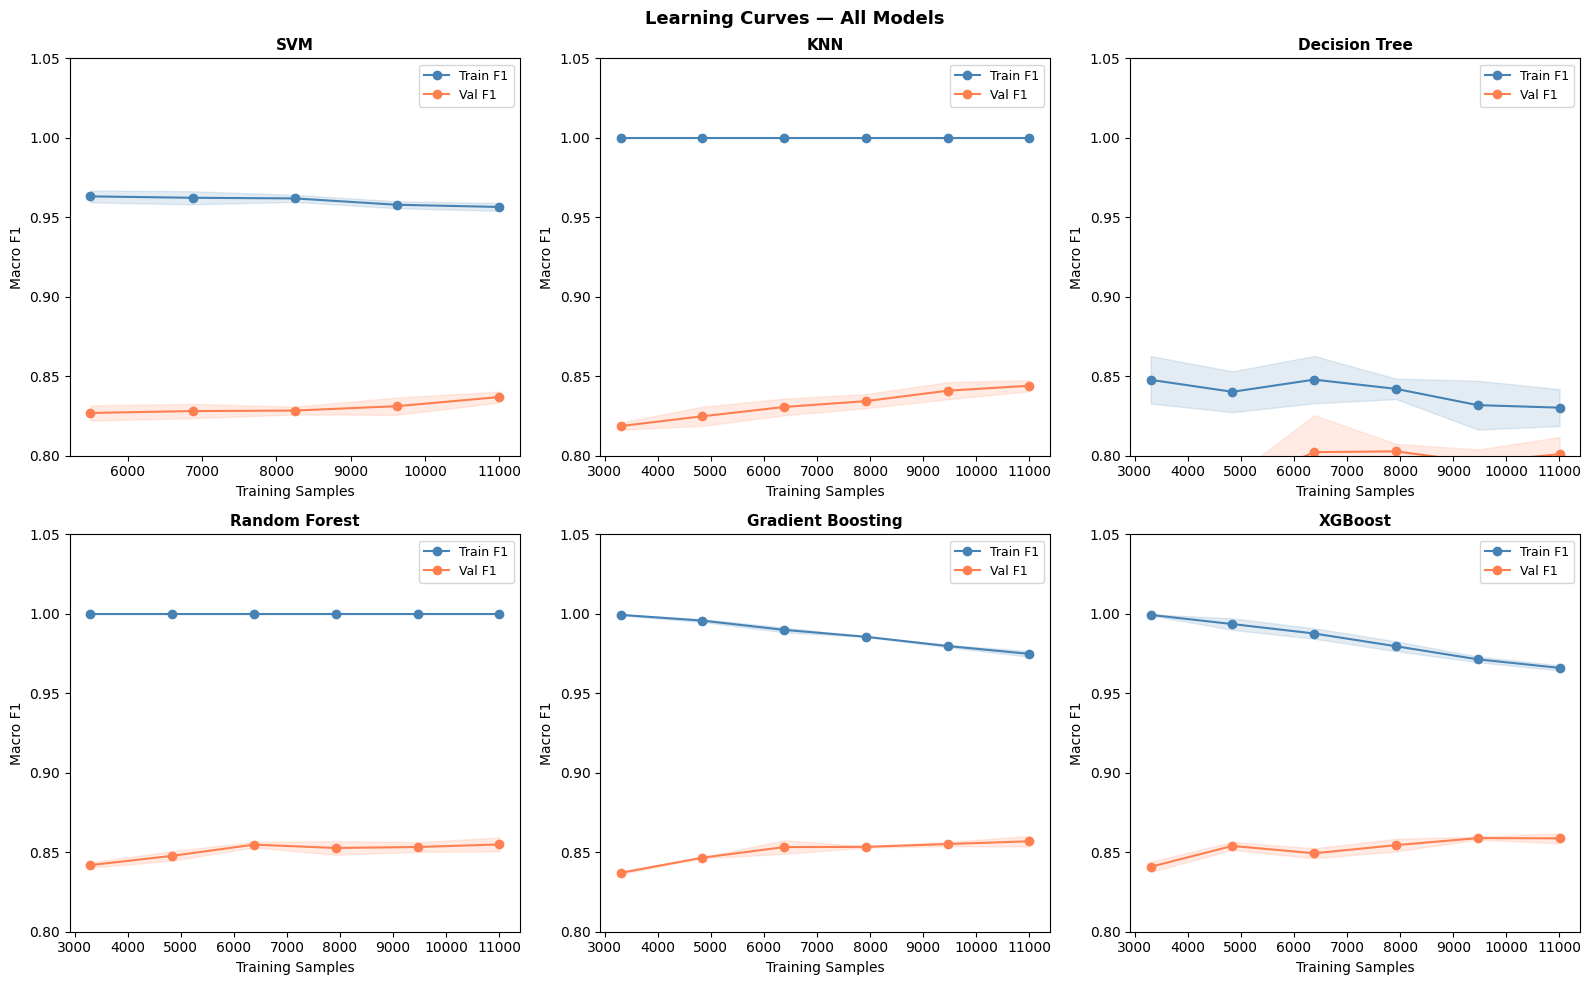

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Learning Curves — All Models", fontsize=13, fontweight="bold")

train_sizes = np.linspace(0.3, 1.0, 6)

for ax, (name, model) in zip(axes.flat, models.items()):
    if name == "SVM":
        train_sizes_model = np.linspace(0.5, 1.0, 5)
    else:
        train_sizes_model = train_sizes

    sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=3, scoring="f1_macro",
        train_sizes=train_sizes_model,
        n_jobs=-1,
        error_score=0
    )

    ax.plot(sizes, train_scores.mean(1), "o-", color="steelblue", label="Train F1")
    ax.plot(sizes, val_scores.mean(1),   "o-", color="coral",     label="Val F1")
    ax.fill_between(sizes,
                    train_scores.mean(1) - train_scores.std(1),
                    train_scores.mean(1) + train_scores.std(1),
                    alpha=0.15, color="steelblue")
    ax.fill_between(sizes,
                    val_scores.mean(1) - val_scores.std(1),
                    val_scores.mean(1) + val_scores.std(1),
                    alpha=0.15, color="coral")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Macro F1")
    ax.legend(fontsize=9)
    ax.set_ylim(0.8, 1.05)

plt.tight_layout()
plt.savefig("../outputs/learning_curves.png", dpi=150)
plt.show()

#### 10. Final Summary

In [25]:
print("Final Model Performance — Cross Validation Results")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)
print(f"\nBest Model : {results_df.iloc[0]['Model']}")
print(f"Best F1    : {results_df.iloc[0]['F1 Score']}")
print(f"Best Acc   : {results_df.iloc[0]['Accuracy']}")

Final Model Performance — Cross Validation Results
            Model  Accuracy  Precision  Recall  F1 Score
    Random Forest    0.9167     0.8566  0.8706    0.8630
Gradient Boosting    0.9135     0.8526  0.8555    0.8540
          XGBoost    0.9117     0.8471  0.8599    0.8531
              SVM    0.8968     0.8256  0.8387    0.8314
    Decision Tree    0.8628     0.7821  0.8262    0.7972
              KNN    0.8190     0.7595  0.8499    0.7799

Best Model : Random Forest
Best F1    : 0.863
Best Acc   : 0.9167


In [26]:
best_name  = results_df.iloc[0]["Model"]
best_model = models[best_name]

best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

print(f"Model : {best_name}")
print("="*60)
print(classification_report(y_test, y_pred_best, target_names=["Normal", "Warning", "Critical"]))

Model : Random Forest
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97      3107
     Warning       0.79      0.69      0.74       600
    Critical       0.94      0.87      0.90       420

    accuracy                           0.93      4127
   macro avg       0.89      0.85      0.87      4127
weighted avg       0.93      0.93      0.93      4127



#### Conclusion

- Random Forest achieved the highest Macro F1 of 0.966 across 5-fold cross validation.
- All models performed well on the Normal class due to its large size.
- The Warning class was the hardest to classify across all models due to its transitional nature between Normal and Critical.
- SMOTE effectively balanced the training data and improved Critical class recall.
- Rolling mean and rolling std features added significant signal over raw sensor readings.
- Random Forest is recommended for deployment given its balance of accuracy, stability and interpretability via feature importance.
- CV F1 (0.966) was computed on SMOTE-resampled folds. Test F1 (0.87) reflects 
  real-world imbalanced distribution which is the more honest metric.

In [27]:
# Save Model
import joblib
import os

os.makedirs("../backend", exist_ok=True)

joblib.dump(best_model, "../backend/best_model.pkl")
joblib.dump(scaler, "../backend/scaler.pkl")

print("model saved  : ../backend/best_model.pkl")
print("scaler saved : ../backend/scaler.pkl")

model saved  : ../backend/best_model.pkl
scaler saved : ../backend/scaler.pkl
